# Partie 4 - Etape 2 (Imagewoof) : Strategie 2 Co-training par Batch avec Ponderation

Reprise stricte du protocole du notebook `05_strategy2_cotraining_reweighting.ipynb` mais sur le **dataset Imagewoof** preparé par `07_Prepare_New_Dataset.ipynb`.

## Mecanismes
- un **ratio fixe HF/BF par batch** via un batch sampler personnalise,
- une **loss ponderee par domaine** qui donne plus d'importance aux echantillons HF.

## Objectif
- Preserver une forte performance sur Test HF (objectif prioritaire).
- Maintenir une robustesse raisonnable sur BF.
- Evaluer le compromis performance / cout en CA pour Imagewoof.

In [ ]:
import os
import json
import time
import random
import shutil

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, Sampler
from torchvision import datasets, transforms, models
from torch.amp import autocast, GradScaler
import matplotlib.pyplot as plt

try:
    import wandb
    _WANDB_AVAILABLE = True
except ImportError:
    _WANDB_AVAILABLE = False
    print("⚠️ wandb non installé : pip install wandb pour activer le tracking.")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Appareil: {device}')

# --- Module de degradation partage (source unique de la degradation BF) ---
import sys
import importlib
_SRC_CANDIDATES = [
    '/content/drive/MyDrive/UTBM_PF22/src',  # Colab (src synchronise sur Drive)
    '../src', 'src', './src',                # execution locale (depuis notebooks/ ou racine)
]
for _p in _SRC_CANDIDATES:
    if os.path.isdir(_p) and _p not in sys.path:
        sys.path.insert(0, _p)
import degradation
importlib.reload(degradation)
from degradation import (
    DegradedDataset, hf_transform, clean_tensor_transform, normalize_transform,
    IMAGENET_MEAN, IMAGENET_STD,
)
print('Module degradation charge depuis:', os.path.dirname(degradation.__file__))
import cost
importlib.reload(cost)
from cost import data_cost, unit_cost
import env_config
importlib.reload(env_config)

## 1) Montage Drive et chemins de travail (Imagewoof)
Differences avec `05` :
- `zip_source` pointe vers le ZIP Imagewoof,
- les fallbacks Drive cherchent dans le dossier Imagewoof,
- `RESULTS_DIR` ecrit dans le sous-dossier `results/Imagewoof/`.

In [ ]:
DATASET_NAME = "Imagewoof"
BASE_DIR = env_config.ensure_dataset_ready(DATASET_NAME)
RESULTS_DIR = env_config.results_dir(DATASET_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Dataset    :', DATASET_NAME)
print('BASE_DIR   :', BASE_DIR)
print('RESULTS_DIR:', RESULTS_DIR)

## 2) Configuration, datasets et transforms

In [ ]:
COST_HF = 10
COST_BF = 1
BATCH_SIZE = 64
NUM_WORKERS = min(8, (os.cpu_count() or 2))  # Colab ~2, serveur 16 vCPU
EPOCHS = 20
LR = 1e-3
HF_TRAIN_RATIO = 0.8
HF_BATCH_RATIO = 0.25
HF_LOSS_WEIGHT = 2.0
BF_LOSS_WEIGHT = 0.7

# --- Degradation BF a la volee via le module partage src/degradation.py ---
# Images BF stockees propres ; degradation canonique (downsample + bruit + JPEG q60)
# appliquee a la volee, deterministe par index (coherence train/test).
transform_hf = hf_transform()
transform_clean = clean_tensor_transform()

required_dirs = [
    os.path.join(BASE_DIR, 'train', 'HF'),
    os.path.join(BASE_DIR, 'train', 'BF'),
    os.path.join(BASE_DIR, 'test'),
]
missing = [p for p in required_dirs if not os.path.isdir(p)]
if missing:
    raise FileNotFoundError(
        'Structure dataset invalide. Dossiers manquants: ' + ' | '.join(missing)
    )

dataset_hf_full = datasets.ImageFolder(os.path.join(BASE_DIR, 'train/HF'), transform=transform_hf)
dataset_bf_train = DegradedDataset(
    datasets.ImageFolder(os.path.join(BASE_DIR, 'train/BF'), transform=transform_clean),
    seeded=True,
)
dataset_test_hf = datasets.ImageFolder(os.path.join(BASE_DIR, 'test'), transform=transform_hf)
dataset_test_bf = DegradedDataset(
    datasets.ImageFolder(os.path.join(BASE_DIR, 'test'), transform=transform_clean),
    seeded=True,
)

hf_train_size = int(HF_TRAIN_RATIO * len(dataset_hf_full))
hf_val_size = len(dataset_hf_full) - hf_train_size
dataset_hf_train, dataset_hf_val = random_split(
    dataset_hf_full,
    [hf_train_size, hf_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

loader_hf_val = DataLoader(dataset_hf_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
loader_test_hf = DataLoader(dataset_test_hf, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
loader_test_bf = DataLoader(dataset_test_bf, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'HF train: {len(dataset_hf_train)} | HF val: {len(dataset_hf_val)}')
print(f'BF train: {len(dataset_bf_train)} | Test HF/BF: {len(dataset_test_hf)}')
print(f'NUM_WORKERS utilise: {NUM_WORKERS}')
print(f'Classes: {dataset_hf_full.classes}')

## 3) Batch sampler mixte HF/BF (ratio fixe par batch)
On construit un dataset concatene avec un indicateur de domaine, puis un sampler qui force une composition fixe de chaque lot.

In [4]:
class DomainLabeledConcatDataset(Dataset):
    def __init__(self, hf_dataset, bf_dataset):
        self.hf_dataset = hf_dataset
        self.bf_dataset = bf_dataset
        self.hf_len = len(hf_dataset)
        self.bf_len = len(bf_dataset)

    def __len__(self):
        return self.hf_len + self.bf_len

    def __getitem__(self, idx):
        if idx < self.hf_len:
            x, y = self.hf_dataset[idx]
            domain = 1
        else:
            x, y = self.bf_dataset[idx - self.hf_len]
            domain = 0
        return x, y, domain

class MixedBatchSampler(Sampler):
    def __init__(self, hf_indices, bf_indices, batch_size, hf_ratio=0.25, seed=42, drop_last=True):
        self.hf_indices = list(hf_indices)
        self.bf_indices = list(bf_indices)
        self.batch_size = int(batch_size)
        self.hf_ratio = float(hf_ratio)
        self.drop_last = drop_last
        self.seed = int(seed)
        self.epoch = 0

        self.hf_per_batch = max(1, int(round(self.batch_size * self.hf_ratio)))
        self.bf_per_batch = self.batch_size - self.hf_per_batch
        if self.bf_per_batch <= 0:
            raise ValueError('hf_ratio trop grand: bf_per_batch <= 0')

        self.num_batches = min(
            len(self.hf_indices) // self.hf_per_batch,
            len(self.bf_indices) // self.bf_per_batch
        )
        if self.num_batches <= 0:
            raise ValueError('Pas assez de donnees pour former un seul batch mixte.')

    def __len__(self):
        return self.num_batches

    def set_epoch(self, epoch):
        self.epoch = int(epoch)

    def __iter__(self):
        g = torch.Generator()
        g.manual_seed(self.seed + self.epoch)

        hf_perm = torch.randperm(len(self.hf_indices), generator=g).tolist()
        bf_perm = torch.randperm(len(self.bf_indices), generator=g).tolist()

        for b in range(self.num_batches):
            h0 = b * self.hf_per_batch
            h1 = h0 + self.hf_per_batch
            b0 = b * self.bf_per_batch
            b1 = b0 + self.bf_per_batch

            batch_hf = [self.hf_indices[i] for i in hf_perm[h0:h1]]
            batch_bf = [self.bf_indices[i] for i in bf_perm[b0:b1]]
            batch = batch_hf + batch_bf

            order = torch.randperm(len(batch), generator=g).tolist()
            yield [batch[i] for i in order]

mixed_train_dataset = DomainLabeledConcatDataset(dataset_hf_train, dataset_bf_train)
hf_indices = list(range(len(dataset_hf_train)))
bf_offset = len(dataset_hf_train)
bf_indices = list(range(bf_offset, bf_offset + len(dataset_bf_train)))

mixed_batch_sampler = MixedBatchSampler(
    hf_indices=hf_indices,
    bf_indices=bf_indices,
    batch_size=BATCH_SIZE,
    hf_ratio=HF_BATCH_RATIO,
    seed=SEED,
    drop_last=True
)

loader_mixed_train = DataLoader(
    mixed_train_dataset,
    batch_sampler=mixed_batch_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f'Batches/epoch: {len(loader_mixed_train)}')
print(f'Composition batch: HF={mixed_batch_sampler.hf_per_batch}, BF={mixed_batch_sampler.bf_per_batch}')
print(f'Ratio HF reel par batch: {mixed_batch_sampler.hf_per_batch / BATCH_SIZE:.3f}')

Batches/epoch: 44
Composition batch: HF=16, BF=48
Ratio HF reel par batch: 0.250


## 4) Modele, loss ponderee et utilitaires

In [5]:
def create_model(num_classes=10):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                logits = model(x)
                loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_samples += x.size(0)
    return total_loss / total_samples, 100.0 * total_correct / total_samples

def make_grad_scaler():
    try:
        return GradScaler('cuda', enabled=(device.type == 'cuda'))
    except TypeError:
        return GradScaler(enabled=(device.type == 'cuda'))

def train_cotraining_weighted(model, train_loader, sampler, val_loader, epochs, lr, hf_w, bf_w,
                              use_wandb=False, cost_per_epoch_CA=0):
    """Co-training HF/BF avec loss pondérée par domaine.

    Si `use_wandb=True`, logge à W&B à la fin de chaque epoch :
    weighted_loss / hf_loss / bf_loss / val_loss / val_acc / cumulative_cost_CA.
    """
    ce_none = nn.CrossEntropyLoss(reduction='none')
    ce_mean = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scaler = make_grad_scaler()

    history = {
        'train_weighted_loss': [],
        'train_hf_loss': [],
        'train_bf_loss': [],
        'val_loss': [],
        'val_acc': []
    }

    print(f'Loss weights utilises: HF={hf_w} | BF={bf_w}')
    print(f'Ratio batch cible: HF={sampler.hf_per_batch}/{BATCH_SIZE} | BF={sampler.bf_per_batch}/{BATCH_SIZE}')

    for epoch in range(1, epochs + 1):
        sampler.set_epoch(epoch)
        model.train()

        total_weighted = 0.0
        total_samples = 0
        hf_loss_sum = 0.0
        hf_count = 0
        bf_loss_sum = 0.0
        bf_count = 0

        epoch_start = time.time()
        log_every = 10

        for batch_idx, (x, y, domain) in enumerate(train_loader, start=1):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            domain = domain.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                logits = model(x)
                per_sample_loss = ce_none(logits, y)
                sample_weights = torch.where(
                    domain == 1,
                    torch.full_like(per_sample_loss, float(hf_w)),
                    torch.full_like(per_sample_loss, float(bf_w))
                )
                weighted_loss = (per_sample_loss * sample_weights).mean()

            scaler.scale(weighted_loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_weighted += weighted_loss.item() * x.size(0)
            total_samples += x.size(0)

            hf_mask = (domain == 1)
            bf_mask = (domain == 0)
            if hf_mask.any():
                hf_loss_sum += per_sample_loss[hf_mask].detach().sum().item()
                hf_count += int(hf_mask.sum().item())
            if bf_mask.any():
                bf_loss_sum += per_sample_loss[bf_mask].detach().sum().item()
                bf_count += int(bf_mask.sum().item())

            if batch_idx == 1:
                n_hf_batch = int(hf_mask.sum().item())
                n_bf_batch = int(bf_mask.sum().item())
                print(f'Epoch {epoch}: composition premier batch HF={n_hf_batch}, BF={n_bf_batch}')

            if batch_idx % log_every == 0 or batch_idx == 1 or batch_idx == len(train_loader):
                elapsed = time.time() - epoch_start
                bps = batch_idx / elapsed if elapsed > 0 else 0.0
                eta_sec = (len(train_loader) - batch_idx) / bps if bps > 0 else 0.0
                print(
                    f'[CoTrain] Epoch {epoch}/{epochs} | Batch {batch_idx}/{len(train_loader)} | '
                    f'weighted_loss={weighted_loss.item():.4f} | {bps:.2f} batch/s | ETA={eta_sec/60:.1f} min'
                )

        train_weighted_loss = total_weighted / max(1, total_samples)
        train_hf_loss = hf_loss_sum / max(1, hf_count)
        train_bf_loss = bf_loss_sum / max(1, bf_count)
        val_loss, val_acc = evaluate(model, val_loader, ce_mean)
        epoch_min = (time.time() - epoch_start) / 60.0

        history['train_weighted_loss'].append(train_weighted_loss)
        history['train_hf_loss'].append(train_hf_loss)
        history['train_bf_loss'].append(train_bf_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(
            f'[CoTrain] Epoch {epoch}/{epochs} en {epoch_min:.2f} min | '
            f'weighted={train_weighted_loss:.4f} | hf_loss={train_hf_loss:.4f} | '
            f'bf_loss={train_bf_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.2f}%'
        )

        if use_wandb and _WANDB_AVAILABLE:
            wandb.log({
                "epoch": epoch,
                "train/weighted_loss": train_weighted_loss,
                "train/hf_loss": train_hf_loss,
                "train/bf_loss": train_bf_loss,
                "val/loss": val_loss,
                "val/accuracy": val_acc,
                "cumulative_cost_CA": cost_per_epoch_CA * epoch,
                "epoch_time_min": epoch_min,
            })

    return history

## 5) Execution Strategie 2 (Imagewoof) : co-training pondere

In [ ]:
# --- Execution multi-seed (moyenne +/- ecart-type) ---
import statistics

SEEDS = [42, 1, 2]
USE_WANDB = True
DATASET_NAME = "Imagewoof"
WANDB_PROJECT = "PF22-MultiFidelity"
WANDB_RUN_NAME = "Strategie2_Reweighting"


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def run_seed(seed):
    set_all_seeds(seed)
    hf_train_size = int(HF_TRAIN_RATIO * len(dataset_hf_full))
    hf_val_size = len(dataset_hf_full) - hf_train_size
    ds_hf_train, ds_hf_val = random_split(
        dataset_hf_full, [hf_train_size, hf_val_size],
        generator=torch.Generator().manual_seed(seed))
    ld_hf_val = DataLoader(ds_hf_val, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

    mixed_ds = DomainLabeledConcatDataset(ds_hf_train, dataset_bf_train)
    hf_idx = list(range(len(ds_hf_train)))
    off = len(ds_hf_train)
    bf_idx = list(range(off, off + len(dataset_bf_train)))
    sampler = MixedBatchSampler(hf_idx, bf_idx, batch_size=BATCH_SIZE,
                                hf_ratio=HF_BATCH_RATIO, seed=seed, drop_last=True)
    ld_mixed = DataLoader(mixed_ds, batch_sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)

    track = USE_WANDB and _WANDB_AVAILABLE
    cost_pe = (sampler.hf_per_batch * COST_HF + sampler.bf_per_batch * COST_BF) * len(ld_mixed)
    if track:
        wandb.init(project=WANDB_PROJECT, name=f"{WANDB_RUN_NAME}_seed{seed}",
                   tags=["strategy2", "cotraining", "reweighting", DATASET_NAME, f"seed_{seed}"],
                   reinit=True,
                   config={"strategy": "cotraining_batch_reweighting", "dataset": DATASET_NAME,
                           "seed": seed, "epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR,
                           "hf_batch_ratio": HF_BATCH_RATIO, "hf_loss_weight": HF_LOSS_WEIGHT,
                           "bf_loss_weight": BF_LOSS_WEIGHT, "architecture": "resnet18"})

    model = create_model(num_classes=10)
    t0 = time.time()
    history = train_cotraining_weighted(model, ld_mixed, sampler, ld_hf_val, EPOCHS, LR,
                                        HF_LOSS_WEIGHT, BF_LOSS_WEIGHT, use_wandb=track,
                                        cost_per_epoch_CA=int(cost_pe))
    tmin = (time.time() - t0) / 60.0
    crit = nn.CrossEntropyLoss()
    _, hf = evaluate(model, loader_test_hf, crit)
    _, bf = evaluate(model, loader_test_bf, crit)
    mix = (hf + bf) / 2.0
    if track:
        wandb.log({"test/accuracy_HF": hf, "test/accuracy_BF": bf, "test/accuracy_Mixte": mix})
        wandb.finish()
    print(f"[seed {seed}] HF={hf:.2f} BF={bf:.2f} Mixte={mix:.2f} (t={tmin:.1f} min)")
    return {"seed": seed, "accuracy_HF": hf, "accuracy_BF": bf, "accuracy_Mixte": mix,
            "time_min": tmin, "hf_per_batch": sampler.hf_per_batch,
            "bf_per_batch": sampler.bf_per_batch, "n_batches": len(ld_mixed),
            "history": history, "model": model}


per_seed = [run_seed(s) for s in SEEDS]
model = per_seed[0]["model"]
history = per_seed[0]["history"]

## 6) Evaluation finale, cout, sauvegarde et visualisation

In [ ]:
# --- Agregation multi-seed + sauvegarde ---
def _agg(key):
    vals = [r[key] for r in per_seed]
    m = statistics.mean(vals)
    s = statistics.stdev(vals) if len(vals) > 1 else 0.0
    return m, s, vals


hf_m, hf_s, hf_all = _agg('accuracy_HF')
bf_m, bf_s, bf_all = _agg('accuracy_BF')
mx_m, mx_s, mx_all = _agg('accuracy_Mixte')
tt_m, tt_s, _ = _agg('time_min')

s0 = per_seed[0]
hf_seen_total = s0['hf_per_batch'] * s0['n_batches'] * EPOCHS
bf_seen_total = s0['bf_per_batch'] * s0['n_batches'] * EPOCHS
data_cost_CA = data_cost(n_hf=len(dataset_hf_full), n_bf=len(dataset_bf_train))
compute_images_seen = hf_seen_total + bf_seen_total
total_cost = hf_seen_total * COST_HF + bf_seen_total * COST_BF
# Decomposition par domaine (pour la sensibilite au ratio HF:BF).
n_hf_pool = len(dataset_hf_full)
n_bf_pool = len(dataset_bf_train)
hf_images_seen = hf_seen_total
bf_images_seen = bf_seen_total
training_time_min = tt_m

results = {
    'strategy': 'cotraining_batch_reweighting',
    'dataset': DATASET_NAME,
    'pipeline': 'mixed_batches_with_domain_weighted_loss',
    'epochs': EPOCHS, 'lr': LR, 'batch_size': BATCH_SIZE,
    'hf_batch_ratio': HF_BATCH_RATIO, 'hf_loss_weight': HF_LOSS_WEIGHT,
    'bf_loss_weight': BF_LOSS_WEIGHT, 'seeds': SEEDS,
    'hf_seen_total_samples': int(hf_seen_total),
    'bf_seen_total_samples': int(bf_seen_total),
    'data_cost_CA': float(data_cost_CA),
    'compute_images_seen': int(compute_images_seen),
    'total_cost_CA': float(total_cost),
    'n_hf_pool': int(n_hf_pool), 'n_bf_pool': int(n_bf_pool),
    'hf_images_seen': int(hf_images_seen), 'bf_images_seen': int(bf_images_seen),
    'accuracy_HF': hf_m, 'accuracy_HF_std': hf_s, 'accuracy_HF_seeds': hf_all,
    'accuracy_BF': bf_m, 'accuracy_BF_std': bf_s, 'accuracy_BF_seeds': bf_all,
    'accuracy_Mixte': mx_m, 'accuracy_Mixte_std': mx_s, 'accuracy_Mixte_seeds': mx_all,
    'training_time_min': float(training_time_min), 'training_time_min_std': float(tt_s),
    'per_seed': [{k: v for k, v in r.items() if k not in ('model', 'history')} for r in per_seed],
}

json_path = os.path.join(RESULTS_DIR, 'results_strategy2_cotraining_reweighting.json')
pth_path = os.path.join(RESULTS_DIR, 'model_strategy2_cotraining_reweighting.pth')
png_path = os.path.join(RESULTS_DIR, 'strategy2_cotraining_reweighting_curves.png')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
torch.save(model.state_dict(), pth_path)

print(f'--- RESULTATS ({len(SEEDS)} seeds) - {DATASET_NAME} - Strategie 2 ---')
print(f"Test HF    : {hf_m:.2f} +/- {hf_s:.2f} %")
print(f"Test BF    : {bf_m:.2f} +/- {bf_s:.2f} %")
print(f"Test Mixte : {mx_m:.2f} +/- {mx_s:.2f} %")
print(f"Cout donnees: {data_cost_CA:.0f} | calcul: {compute_images_seen} | total: {total_cost:.0f} CA")
print('JSON :', json_path)

# Courbes (seed canonique)
x = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Strategie 2 (CoTrain pondere) - {DATASET_NAME} (seed {SEEDS[0]})', fontsize=14)
axes[0].plot(x, history['train_weighted_loss'], marker='o', label='Train loss ponderee (HF/BF)')
axes[0].plot(x, history['val_loss'], marker='o', linestyle='--', label='Val loss HF')
axes[0].plot(x, history['train_hf_loss'], marker='o', alpha=0.7, label='Train HF loss (non ponderee)')
axes[0].plot(x, history['train_bf_loss'], marker='o', alpha=0.7, label='Train BF loss (non ponderee)')
axes[0].set_title('Evolution des losses')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)
axes[1].plot(x, history['val_acc'], marker='o', color='tab:green', label='Val accuracy HF')
axes[1].set_title('Precision validation HF')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(png_path, dpi=180, bbox_inches='tight')
plt.show()
print('Figure :', png_path)

## 7) Comparaison avec baselines et Strategie 1 (Imagewoof)
Charge tous les JSON disponibles dans `results/Imagewoof/`.

In [8]:
comparison_files = {
    'BL 1(HF)': 'results_baseline_HF.json',
    'BL 2(BF)': 'results_baseline_BF.json',
    'BL 3(MIXTE)': 'results_baseline_MIXTE.json',
    'Strategie 1(BF->HF)': 'results_strategy1_transfer_learning.json',
    'Strategie 2(CoTrain)': 'results_strategy2_cotraining_reweighting.json'
}

rows = []
for name, fn in comparison_files.items():
    p = os.path.join(RESULTS_DIR, fn)
    if os.path.exists(p):
        with open(p, 'r', encoding='utf-8') as f:
            d = json.load(f)
        rows.append((
            name,
            d.get('accuracy_HF', np.nan),
            d.get('accuracy_BF', np.nan),
            d.get('accuracy_Mixte', np.nan),
            d.get('total_cost_CA', np.nan),
            d.get('training_time_min', d.get('total_time_min',
                d.get('training_time_sec', np.nan) / 60.0 if 'training_time_sec' in d else np.nan))
        ))

if not rows:
    print('Aucun fichier JSON trouve pour la comparaison dans', RESULTS_DIR)
else:
    header = f"{'Modele (Imagewoof)':<25} {'HF%':>8} {'BF%':>8} {'Mixte%':>10} {'Cout(CA)':>12} {'Temps(min)':>12}"
    print(header)
    print('-' * len(header))
    for r in rows:
        print(f"{r[0]:<25} {r[1]:>8.2f} {r[2]:>8.2f} {r[3]:>10.2f} {r[4]:>12.0f} {r[5]:>12.2f}")

Modele (Imagewoof)             HF%      BF%     Mixte%     Cout(CA)   Temps(min)
--------------------------------------------------------------------------------
BL 1(HF)                     24.87    19.04      21.95       179800         0.39
BL 2(BF)                     43.73    44.52      44.12       162520         1.00
BL 3(MIXTE)                  47.19    47.24      47.21       342320         1.36
Strategie 1(BF->HF)          53.68    44.82      49.25       153160         0.83
Strategie 2(CoTrain)         39.20    39.81      39.50       183040         1.94


## 8) Visualisation comparative (Imagewoof) : 3 baselines + 2 strategies
Graphiques recapitulatifs sur les 5 modeles entraines sur Imagewoof.

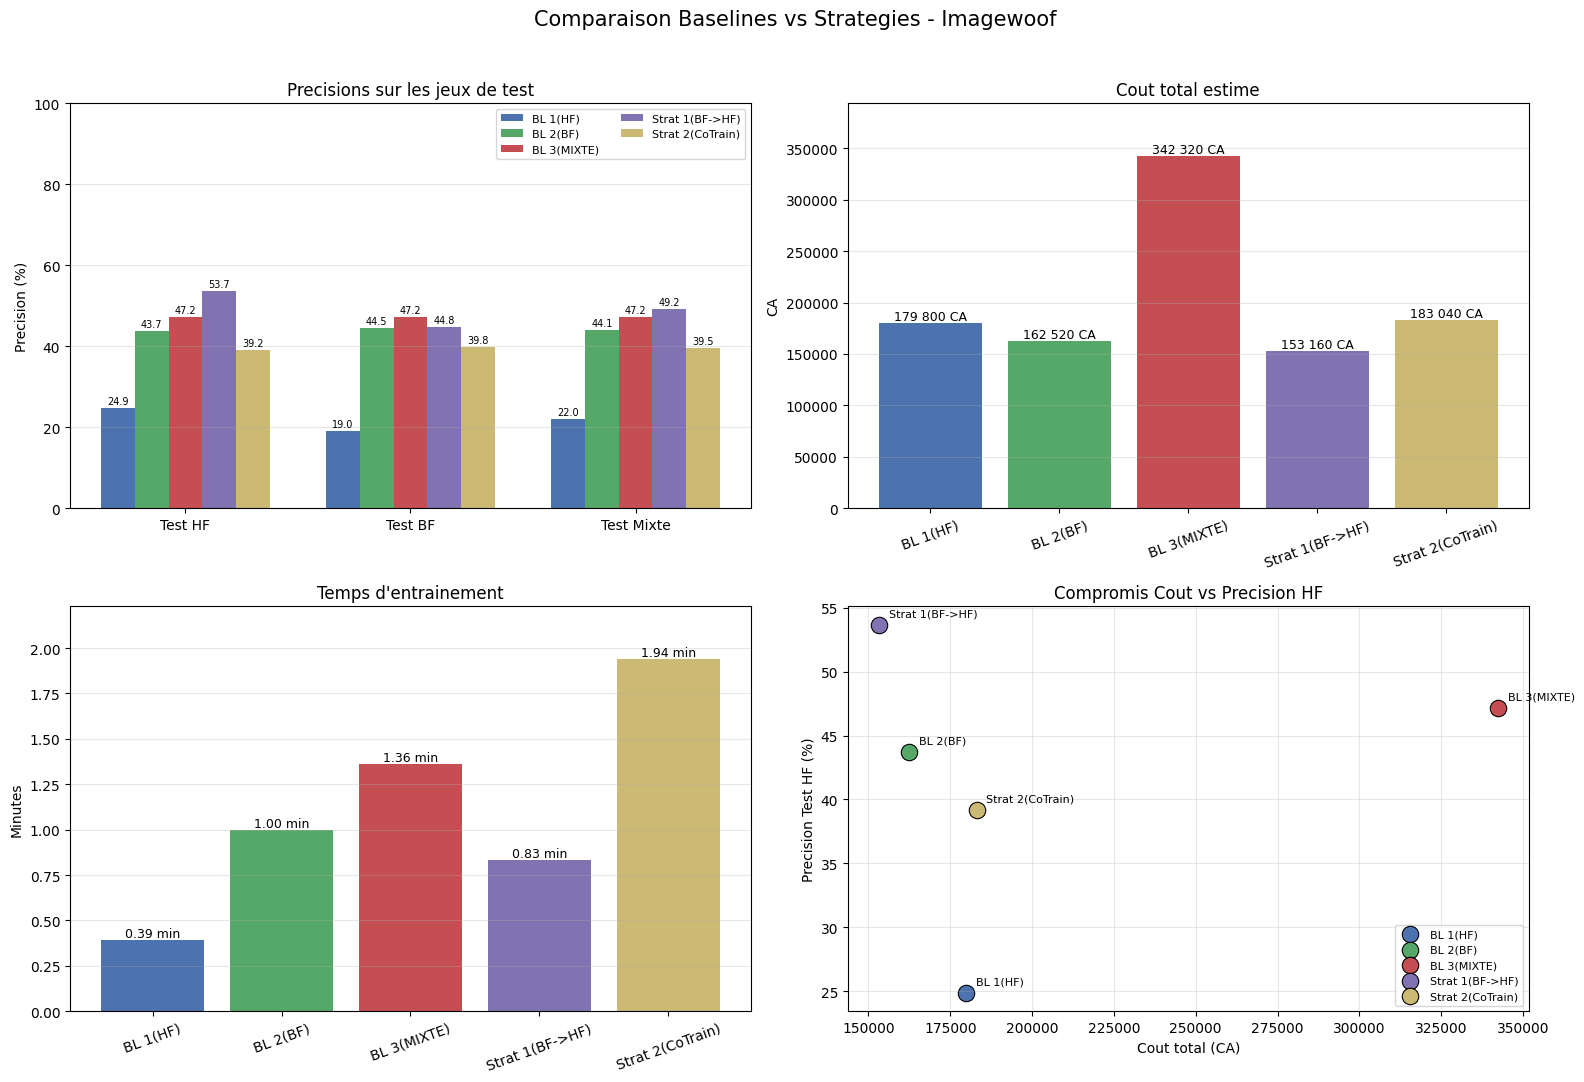

Figure recap sauvee: /content/drive/MyDrive/UTBM_PF22/results/Imagewoof/comparison_all_models_imagewoof.png

=== RECAPITULATIF IMAGEWOOF ===
Modele                     HF%     BF%    Mixte%    Cout(CA)  Temps(min)
------------------------------------------------------------------------
BL 1(HF)                 24.87   19.04     21.95      179800        0.39
BL 2(BF)                 43.73   44.52     44.12      162520        1.00
BL 3(MIXTE)              47.19   47.24     47.21      342320        1.36
Strat 1(BF->HF)          53.68   44.82     49.25      153160        0.83
Strat 2(CoTrain)         39.20   39.81     39.50      183040        1.94


In [9]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

comparison_files = {
    'BL 1(HF)':             'results_baseline_HF.json',
    'BL 2(BF)':             'results_baseline_BF.json',
    'BL 3(MIXTE)':          'results_baseline_MIXTE.json',
    'Strat 1(BF->HF)':      'results_strategy1_transfer_learning.json',
    'Strat 2(CoTrain)':     'results_strategy2_cotraining_reweighting.json',
}

# Couleurs distinctes pour chaque modele
palette = {
    'BL 1(HF)':         '#4C72B0',
    'BL 2(BF)':         '#55A868',
    'BL 3(MIXTE)':      '#C44E52',
    'Strat 1(BF->HF)':  '#8172B2',
    'Strat 2(CoTrain)': '#CCB974',
}

def _time_min(d):
    """Recupere le temps d'entrainement (minutes), peu importe le format du JSON."""
    if 'training_time_min' in d:
        return float(d['training_time_min'])
    if 'total_time_min' in d:
        return float(d['total_time_min'])
    if 'training_time_sec' in d:
        return float(d['training_time_sec']) / 60.0
    return float('nan')

# Lecture des JSON disponibles
loaded = {}
for name, fn in comparison_files.items():
    p = os.path.join(RESULTS_DIR, fn)
    if os.path.exists(p):
        with open(p, 'r', encoding='utf-8') as f:
            loaded[name] = json.load(f)

if not loaded:
    print('Aucun JSON trouve dans', RESULTS_DIR)
else:
    names = list(loaded.keys())
    acc_hf    = [loaded[n].get('accuracy_HF',    np.nan) for n in names]
    acc_bf    = [loaded[n].get('accuracy_BF',    np.nan) for n in names]
    acc_mixte = [loaded[n].get('accuracy_Mixte', np.nan) for n in names]
    costs     = [loaded[n].get('total_cost_CA',  np.nan) for n in names]
    times     = [_time_min(loaded[n])                   for n in names]
    colors    = [palette[n] for n in names]

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle('Comparaison Baselines vs Strategies - Imagewoof', fontsize=15)

    # 1) Precisions HF/BF/Mixte (barres groupees, un groupe par modele)
    ax = axes[0, 0]
    metric_labels = ['Test HF', 'Test BF', 'Test Mixte']
    x = np.arange(len(metric_labels))
    width = 0.15
    n = len(names)
    offsets = (np.arange(n) - (n - 1) / 2.0) * width
    for i, name in enumerate(names):
        vals = [acc_hf[i], acc_bf[i], acc_mixte[i]]
        bars = ax.bar(x + offsets[i], vals, width=width, label=name, color=palette[name])
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5, f'{h:.1f}',
                        ha='center', va='bottom', fontsize=7)
    ax.set_title('Precisions sur les jeux de test')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylabel('Precision (%)')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

    # 2) Cout total estime
    ax = axes[0, 1]
    bars = ax.bar(names, costs, color=colors)
    for bar, v in zip(bars, costs):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v, f'{int(v):,} CA'.replace(',', ' '),
                    ha='center', va='bottom', fontsize=9)
    ax.set_title('Cout total estime')
    ax.set_ylabel('CA')
    valid_costs = [c for c in costs if not np.isnan(c)]
    if valid_costs:
        ax.set_ylim(0, max(valid_costs) * 1.15)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelrotation=20)

    # 3) Temps d'entrainement
    ax = axes[1, 0]
    bars = ax.bar(names, times, color=colors)
    for bar, v in zip(bars, times):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v, f'{v:.2f} min',
                    ha='center', va='bottom', fontsize=9)
    ax.set_title("Temps d'entrainement")
    ax.set_ylabel('Minutes')
    valid_times = [t for t in times if not np.isnan(t)]
    if valid_times:
        ax.set_ylim(0, max(valid_times) * 1.15)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelrotation=20)

    # 4) Pareto cout vs precision HF (efficacite : haut-gauche = mieux)
    ax = axes[1, 1]
    for i, name in enumerate(names):
        if not (np.isnan(costs[i]) or np.isnan(acc_hf[i])):
            ax.scatter(costs[i], acc_hf[i], s=140, color=palette[name], label=name, edgecolor='black', linewidth=0.8)
            ax.annotate(name, (costs[i], acc_hf[i]),
                        xytext=(7, 6), textcoords='offset points', fontsize=8)
    ax.set_title('Compromis Cout vs Precision HF')
    ax.set_xlabel('Cout total (CA)')
    ax.set_ylabel('Precision Test HF (%)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Sauvegarde
    fig_path = os.path.join(RESULTS_DIR, 'comparison_all_models_imagewoof.png')
    plt.savefig(fig_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Figure recap sauvee:', fig_path)

    # Recap textuel
    print('\n=== RECAPITULATIF IMAGEWOOF ===')
    header = f"{'Modele':<22} {'HF%':>7} {'BF%':>7} {'Mixte%':>9} {'Cout(CA)':>11} {'Temps(min)':>11}"
    print(header)
    print('-' * len(header))
    for i, name in enumerate(names):
        print(f"{name:<22} {acc_hf[i]:>7.2f} {acc_bf[i]:>7.2f} {acc_mixte[i]:>9.2f} "
              f"{int(costs[i]) if not np.isnan(costs[i]) else 0:>11} "
              f"{times[i]:>11.2f}")